## Normalizing Flow Model

1. This Family of Model transforms simple distribution via series of Invertible transoformations to capture more complex distribution
2. Invertible transoformations enables exact density evaluation of the transformed distribution via Change of variables formula?
3. If we design the flow transformation architecture well enough to model the complex distribuition and the inverse with Jacobian easily computable we can learn the distribuition via `Normalizing Flow Model` family

## Assumptions
1. The series of transformation we are using must be Invertible, because for sampling we need g(x) and for likelihood computation we need g^-1(x)
2. Be sufficiently expressive to model the distribution of Interest
3. must be computationally efficient, both in terms of computing g^-1(x), g(x) but also in terms of calculating the Jacobian

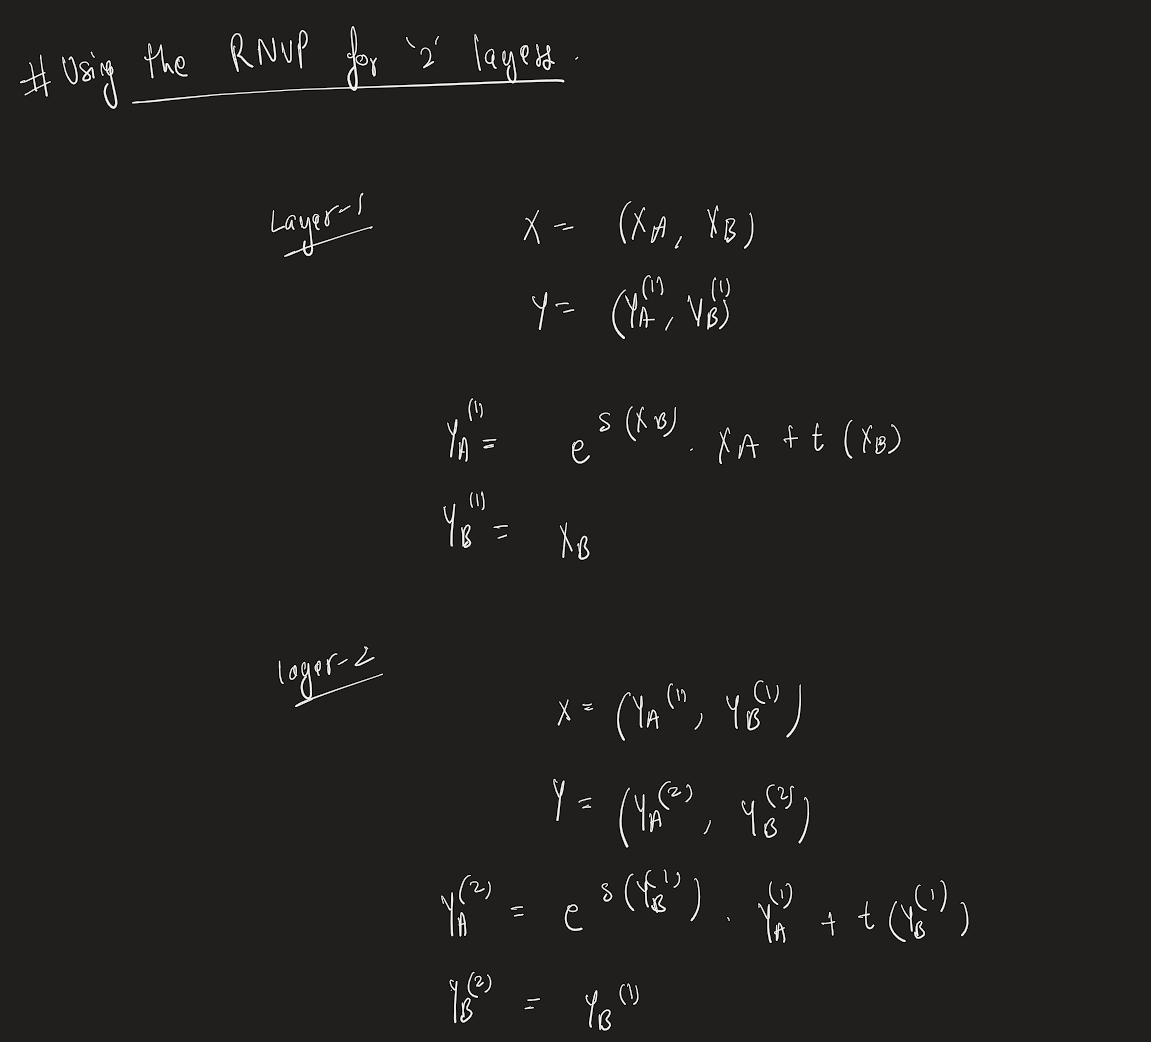

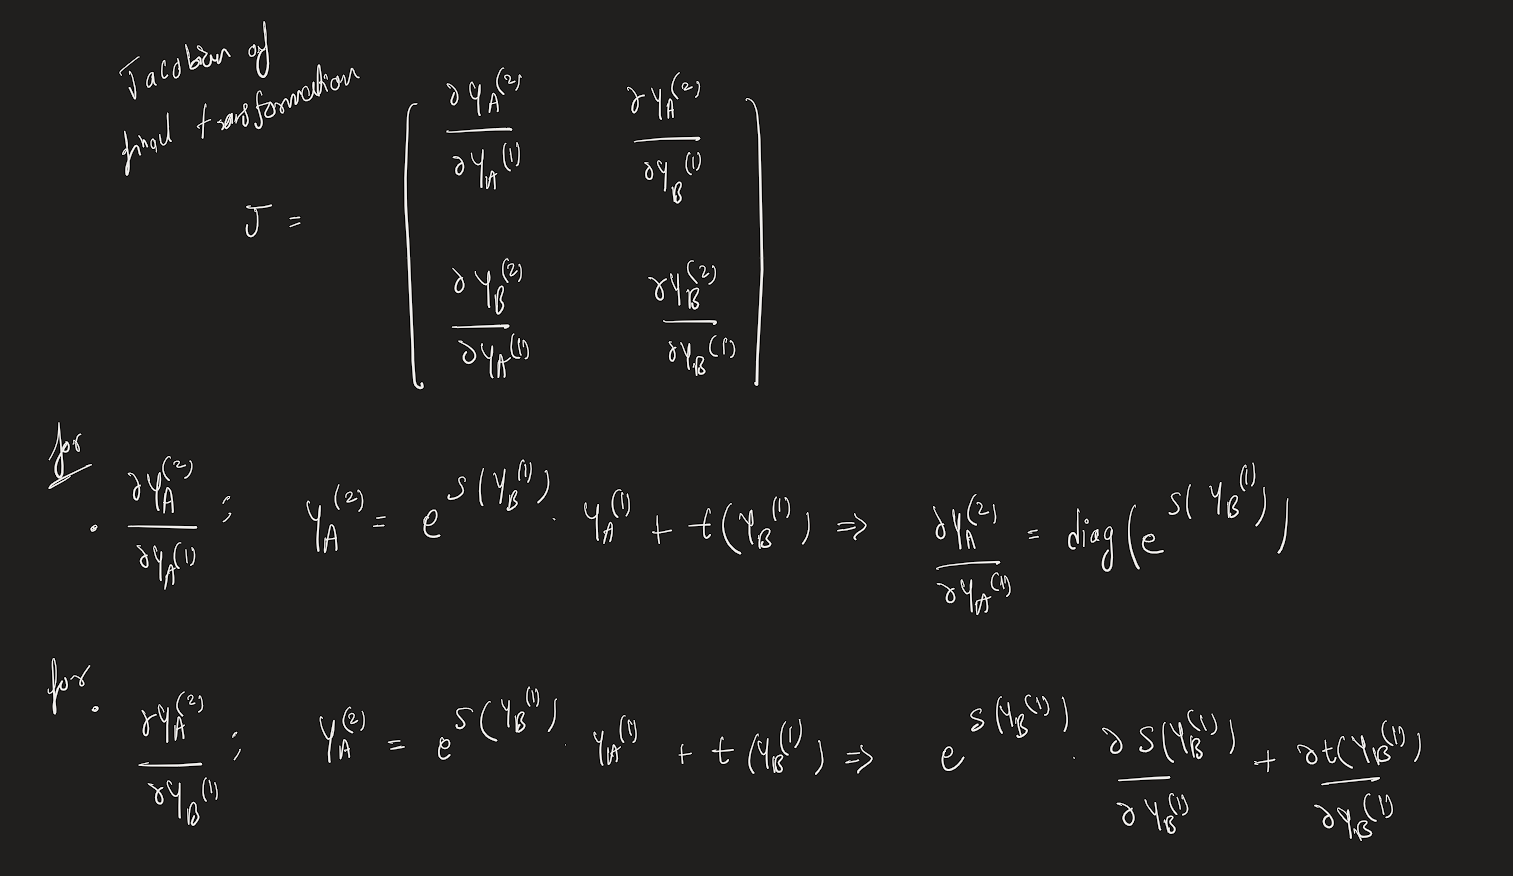

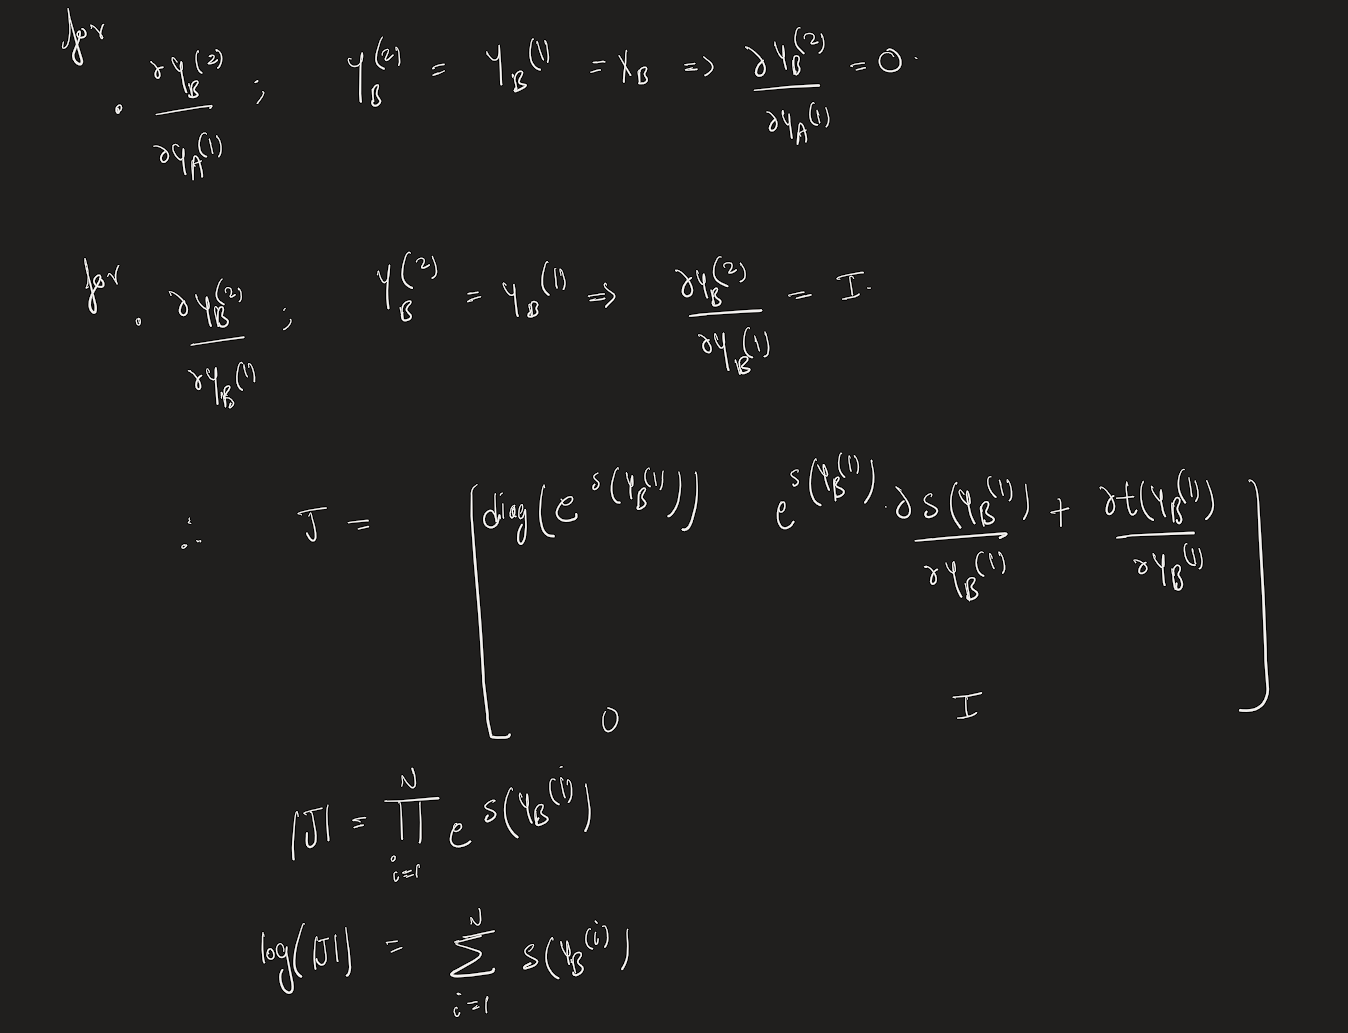

## Architecture Design from scratch

In [1]:
import torch.nn as nn
import torch
import torch.nn.functional as F

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Linear Layer

In [3]:
class LinearLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = torch.nn.Parameter(torch.rand(self.in_features, self.out_features))
        self.bias = torch.nn.Parameter(torch.zeros(self.out_features))

        nn.init.xavier_normal_(self.weight.T)
    
    def forward(self, x: torch.tensor):
        return x @ self.weight + self.bias

## Layer Normalization

In [4]:
class LayerNorm(nn.Module):
    def __init__(self, in_features: int, eps: int = 0.001):
        super().__init__()
        self.in_features = in_features
        self.eps = eps

        self.alpha = torch.nn.Parameter(torch.ones(self.in_features))
        self.beta = torch.nn.Parameter(torch.zeros(self.in_features))
    
    def forward(self, x: torch.tensor):
        x_mean = torch.mean(x, dim = -1, keepdim = True)
        x_var = torch.var(x, dim = -1, keepdim = True, unbiased = False)
        x_norm = (x - x_mean) / (torch.sqrt(x_var  +self.eps))

        return x_norm * self.alpha + self.beta

## NeuralNetwork for adjusting the scale and shift of transformation of x_a based on x_b

In [5]:
class ScaleAndShiftNetwork(nn.Module):
    def __init__(self, in_features: int, hidden_dim: int, out_features: int):
        super().__init__()
        self.linear_layer_1 = LinearLayer(in_features, hidden_dim)
        # self.layer_norm_1 = LayerNorm(hidden_dim)
        self.linear_layer_2 = LinearLayer(hidden_dim, hidden_dim)
        # self.layer_norm_2 = LayerNorm(hidden_dim)
        # self.linear_layer_3 = LinearLayer(hidden_dim, hidden_dim)
        # self.layer_norm_3 = LayerNorm(hidden_dim)
        # self.linear_layer_4 = LinearLayer(hidden_dim, hidden_dim)
        # self.layer_norm_4 = LayerNorm(hidden_dim)
        # self.linear_layer_5 = LinearLayer(hidden_dim, hidden_dim)
        # self.layer_norm_5 = LayerNorm(hidden_dim)
        self.scale_layer = LinearLayer(hidden_dim, out_features)
        self.shift_layer = LinearLayer(hidden_dim, out_features)
        nn.init.zeros_(self.scale_layer.weight)
        nn.init.zeros_(self.scale_layer.bias)
        nn.init.zeros_(self.shift_layer.weight)
        nn.init.zeros_(self.shift_layer.bias)
    
    def forward(self, x: torch.tensor):
        h1 = self.linear_layer_1(x)
        # h1_norm = self.layer_norm_1(h1)
        # a1 = torch.tanh(h1_norm)
        a1 = torch.relu(h1)
        h2 = self.linear_layer_2(a1)
        # h2_norm = self.layer_norm_2(h2)
        # h3 = self.linear_layer_3(h2_norm)
        a2 = torch.relu(h2)
        # h3_norm = self.layer_norm_3(h3)
        # h4 = self.linear_layer_4(h3_norm)
        # h4_norm = self.layer_norm_4(h4)

        # h5 = self.linear_layer_5(h4_norm)
        # h5_norm = self.layer_norm_5(h5)
        # a2 = torch.tanh(h5_norm)

        # scale = torch.tanh(self.scale_layer(a2))
        scale = 2.0 * torch.tanh(self.scale_layer(a2) / 2.0)
        shift = self.shift_layer(a2)

        # print("---------------------------------------Debugging---------------------------------------")
        # print(f"scale.mean() = {scale.mean()}")
        # print(f"scale.std() = {scale.std()}")
        # print()
        # print(f"shift.mean() = {shift.mean()}")
        # print(f"shift.std() = {shift.std()}")

        return scale, shift

## Defining each Invertible Function Mapping

In [6]:
class InvertibleFunction(nn.Module):
    def __init__(self, in_features: int, hidden_dim: int, out_features: int, mask: torch.tensor):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.mask = mask
        self.scale_shift_network = ScaleAndShiftNetwork(in_features//2, hidden_dim, in_features//2)
    
    def forward(self, x: torch.tensor):
        x_a, x_b, mask_bool = self.split_x(x)
        scale, shift = self.scale_shift_network(x_b)
        y_a = x_a * torch.exp(scale) + shift
        y_b = x_b

        y = torch.zeros_like(x)
        y[:, mask_bool] = y_a
        y[:, ~mask_bool] = y_b

        # Each layer contributes to the log(|J|) as, log(|J|) = sum(scale)
        log_det_jacobian = torch.sum(scale, dim = -1)
        return y, log_det_jacobian

    def split_x(self, x: torch.tensor):
        mask_bool = self.mask.squeeze(0).bool()
        x_a = x[:, mask_bool]
        x_b = x[:, ~mask_bool]
        return x_a, x_b, mask_bool
    
    def inverse_transformation(self, y: torch.tensor, scale_shift_network: ScaleAndShiftNetwork):
        """
        Computing the inverse of this Invertible transformation h(x1, x2) = (exp(scale(x2)) * x1 + shift(x2), x2) = (y1, y2)
        y1 = exp(scale(x2)) * x1 + shift(x2) and y2 = x2

        Inverse Mapping: 
        x1 = (y1 - shift(x2)) * exp(-(scale(x2))) and x2 = y2
        we can recover the exact value of x1 and x2 from y1 and y2 via the transformaion (y1, y2) = h(x1, x2) if 'h' is invertible, which in our case is
        """
        mask_bool = self.mask.squeeze(0).bool()
        y1, y2 = y[:, mask_bool], y[:, ~mask_bool]
        scale, shift = scale_shift_network(y2)
        x1, x2 = (y1 - shift) * torch.exp(-scale), y2
        x = torch.zeros_like(y)
        x[:, mask_bool] = x1
        x[:, ~mask_bool] = x2
        return x
        
            

## Defining Normalizing Flow Model

In [7]:
class NormalizingFlowModel(nn.Module):
    def __init__(self, in_features: int, hidden_dim: int, out_features: int, mask: torch.tensor, n_layers: int):
        super().__init__()
        assert in_features == out_features, "in_features must be equal to out_feature, for invertible mapping"
        self.layers = nn.ModuleList([
            InvertibleFunction(
                in_features = in_features,
                hidden_dim = hidden_dim,
                out_features = out_features,
                mask = mask[i % len(mask)].unsqueeze(dim = 0)
            )
            for i in range(n_layers)
        ])
    
    def forward(self, x: torch.tensor):
        """
        -> Each layer contributes to the log(|J|) as, log(|J|) = sum(scale), and if there are 'k' number of Invertible transformations then we need to sum if for all k's transformation of each individual 'log(|J|)'
           therefore, for 'k' Invertible transformations log(|J|) = sum_of_all_k's_log_J = sum_no_of_layers(sum(scale))
        -> Log-det adjusts density due to volume change
        """
        total_log_det = 0
        for layer in self.layers:
            x, log_det = layer(x)
            total_log_det += log_det
        
        return x, total_log_det # <--- how much the transformation expands or compresses volume around each data point.
    
    def inverse(self, y: torch.tensor):
        """
        This function will calculate the inverse mapping from y to x, for all intermediate invertible transformations

        -> forward invertible transformations: 
            g(x) = f_k(f_k-1(f_k-2(......(f_2(f_1(x))))))
        -> inverse of g(x): 
            g^-1(x) = composition of inverse of each invertible transformations in reverse direction
        """
        x = y
        for layer in self.layers[::-1]:
            x = layer.inverse_transformation(x, layer.scale_shift_network)
        return x



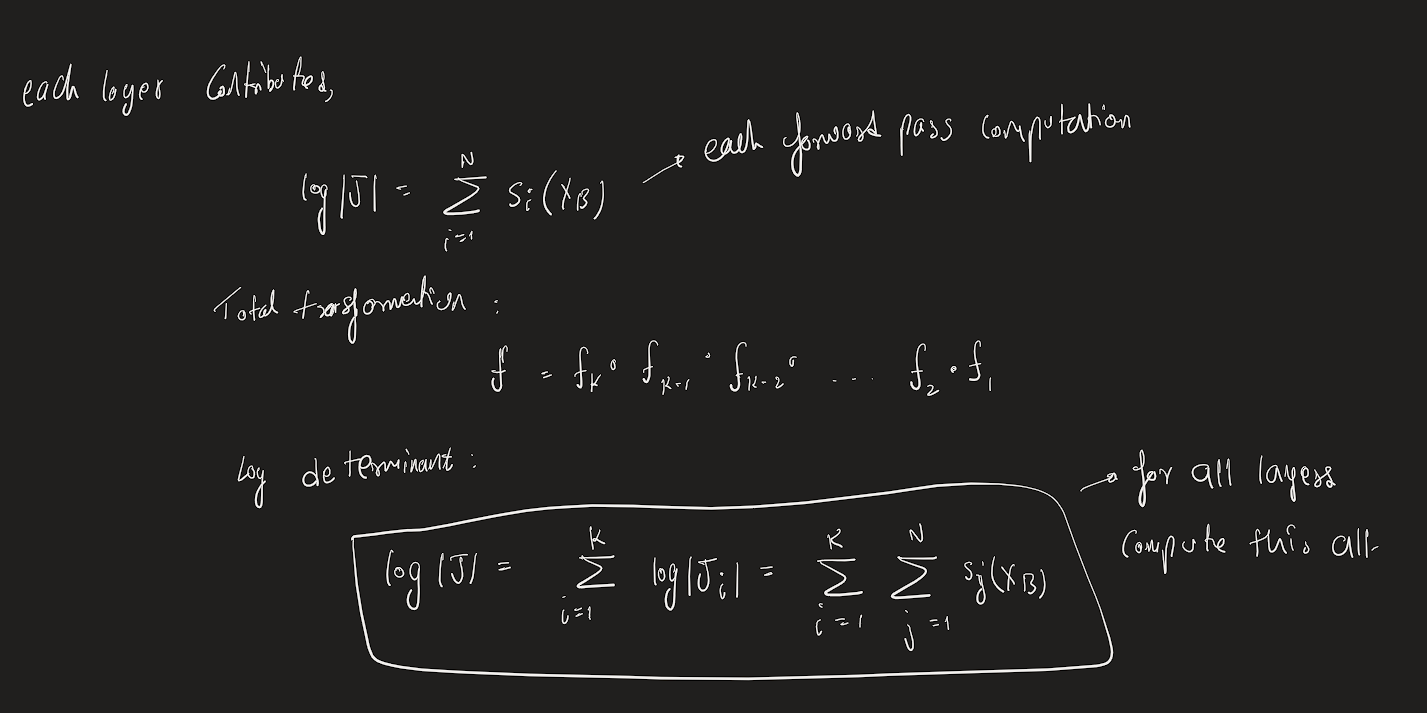

## Dummy Check 

In [8]:
in_features = 6
hidden_dim = 5
out_features = 2
masks = torch.tensor([[1, 1, 1, 0, 0, 0], [0, 0, 0, 1, 1, 1], [1, 0, 1, 0, 1, 0], [0, 1, 0, 1, 0, 1]])
x = torch.rand(10, in_features)

In [9]:
normalizing_flow_model = NormalizingFlowModel(in_features = in_features, hidden_dim = hidden_dim, out_features = in_features, mask = masks, n_layers = 2)
transformed_x, log_det = normalizing_flow_model(x)
print(f"x.shape = {x.shape}")
print(f"transformed_x.shape = {transformed_x.shape}")
print(f"Log det = {log_det}")

x.shape = torch.Size([10, 6])
transformed_x.shape = torch.Size([10, 6])
Log det = tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<AddBackward0>)


In [10]:
print("-" * 100)
print("                                          Architectural Design")
print("-" * 100)
for idx, layer in enumerate(normalizing_flow_model.layers):
    print(f"Layer-{idx+1}: {layer}")

----------------------------------------------------------------------------------------------------
                                          Architectural Design
----------------------------------------------------------------------------------------------------
Layer-1: InvertibleFunction(
  (scale_shift_network): ScaleAndShiftNetwork(
    (linear_layer_1): LinearLayer()
    (linear_layer_2): LinearLayer()
    (scale_layer): LinearLayer()
    (shift_layer): LinearLayer()
  )
)
Layer-2: InvertibleFunction(
  (scale_shift_network): ScaleAndShiftNetwork(
    (linear_layer_1): LinearLayer()
    (linear_layer_2): LinearLayer()
    (scale_layer): LinearLayer()
    (shift_layer): LinearLayer()
  )
)


In [11]:
h = InvertibleFunction(6, 10, 6, masks[0])
y, _ = h(x)
# y1, y2 = y[:, masks[0].bool()], y[:, ~masks[0].bool()]

In [12]:
h.inverse_transformation(y,  h.scale_shift_network)

tensor([[0.0708, 0.7223, 0.6481, 0.4446, 0.3284, 0.4143],
        [0.2230, 0.6899, 0.5938, 0.9109, 0.8972, 0.2416],
        [0.0155, 0.6899, 0.3259, 0.6422, 0.2653, 0.3087],
        [0.5630, 0.9386, 0.8895, 0.0238, 0.0544, 0.2256],
        [0.5039, 0.8251, 0.8200, 0.5525, 0.9271, 0.6745],
        [0.1417, 0.5456, 0.0422, 0.6345, 0.7024, 0.1945],
        [0.4377, 0.1213, 0.7575, 0.7577, 0.9898, 0.2998],
        [0.0961, 0.9606, 0.6068, 0.2404, 0.1069, 0.6328],
        [0.5764, 0.8158, 0.1670, 0.5866, 0.9439, 0.8553],
        [0.7242, 0.2559, 0.8307, 0.6794, 0.4550, 0.6929]],
       grad_fn=<CopySlices>)

In [13]:
# x[:, masks[0].bool()], x[:, ~masks[0].bool()]
x

tensor([[0.0708, 0.7223, 0.6481, 0.4446, 0.3284, 0.4143],
        [0.2230, 0.6899, 0.5938, 0.9109, 0.8972, 0.2416],
        [0.0155, 0.6899, 0.3259, 0.6422, 0.2653, 0.3087],
        [0.5630, 0.9386, 0.8895, 0.0238, 0.0544, 0.2256],
        [0.5039, 0.8251, 0.8200, 0.5525, 0.9271, 0.6745],
        [0.1417, 0.5456, 0.0422, 0.6345, 0.7024, 0.1945],
        [0.4377, 0.1213, 0.7575, 0.7577, 0.9898, 0.2998],
        [0.0961, 0.9606, 0.6068, 0.2404, 0.1069, 0.6328],
        [0.5764, 0.8158, 0.1670, 0.5866, 0.9439, 0.8553],
        [0.7242, 0.2559, 0.8307, 0.6794, 0.4550, 0.6929]])

In [14]:
print("""
Till now:
1. Understood the math, architecture, derived Jacobian for 2 affine coupling layers, understood the change of variables formula
2. Implemented affine coupling layer
3. Computed log(|J|)
4. Computed the inverse mapping for the invertible function

What next:
1. Understand the training logic
2. Understand the sampling logic
3. Implement training loop
4. Train the model
5. sample from the trained model
6. scale this model for better datasets (celebA, etc)
7. Make seperate git repo for this Normalizing flow model and do experimentations with it
""")


Till now:
1. Understood the math, architecture, derived Jacobian for 2 affine coupling layers, understood the change of variables formula
2. Implemented affine coupling layer
3. Computed log(|J|)
4. Computed the inverse mapping for the invertible function

What next:
1. Understand the training logic
2. Understand the sampling logic
3. Implement training loop
4. Train the model
5. sample from the trained model
6. scale this model for better datasets (celebA, etc)
7. Make seperate git repo for this Normalizing flow model and do experimentations with it



In [15]:
x

tensor([[0.0708, 0.7223, 0.6481, 0.4446, 0.3284, 0.4143],
        [0.2230, 0.6899, 0.5938, 0.9109, 0.8972, 0.2416],
        [0.0155, 0.6899, 0.3259, 0.6422, 0.2653, 0.3087],
        [0.5630, 0.9386, 0.8895, 0.0238, 0.0544, 0.2256],
        [0.5039, 0.8251, 0.8200, 0.5525, 0.9271, 0.6745],
        [0.1417, 0.5456, 0.0422, 0.6345, 0.7024, 0.1945],
        [0.4377, 0.1213, 0.7575, 0.7577, 0.9898, 0.2998],
        [0.0961, 0.9606, 0.6068, 0.2404, 0.1069, 0.6328],
        [0.5764, 0.8158, 0.1670, 0.5866, 0.9439, 0.8553],
        [0.7242, 0.2559, 0.8307, 0.6794, 0.4550, 0.6929]])

In [16]:
normalizing_flow_model.inverse(transformed_x)

tensor([[0.0708, 0.7223, 0.6481, 0.4446, 0.3284, 0.4143],
        [0.2230, 0.6899, 0.5938, 0.9109, 0.8972, 0.2416],
        [0.0155, 0.6899, 0.3259, 0.6422, 0.2653, 0.3087],
        [0.5630, 0.9386, 0.8895, 0.0238, 0.0544, 0.2256],
        [0.5039, 0.8251, 0.8200, 0.5525, 0.9271, 0.6745],
        [0.1417, 0.5456, 0.0422, 0.6345, 0.7024, 0.1945],
        [0.4377, 0.1213, 0.7575, 0.7577, 0.9898, 0.2998],
        [0.0961, 0.9606, 0.6068, 0.2404, 0.1069, 0.6328],
        [0.5764, 0.8158, 0.1670, 0.5866, 0.9439, 0.8553],
        [0.7242, 0.2559, 0.8307, 0.6794, 0.4550, 0.6929]],
       grad_fn=<CopySlices>)

In [17]:
LOG_2PI = torch.log(torch.tensor(2 * torch.pi, device=device))
def get_log_pz(z):
    return torch.sum(
        -0.5 * (LOG_2PI + z**2),
        dim = -1
    )

In [18]:
import matplotlib.pyplot as plt
def train_model(X, dataloader, model, epochs, optimizer):
    model.train()
    print(f"Training the Model on [{device}]")
    
    for epoch in range(epochs):
        epoch_loss = 0
        
        for batch in dataloader:
            x_batch = batch[0].to(device)
            
            x_transformed, log_det = model(x_batch)
            log_pz = get_log_pz(x_transformed)
            
            loss = -(log_pz + log_det).mean()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        if epoch % 100 == 0:
            avg_loss = epoch_loss / len(dataloader)
            print(f"Epoch [{epoch} / {epochs}] | Avg Loss: {avg_loss:.4f}")
            
            # Plotting Latent Space
            model.eval()
            with torch.no_grad():
                # We use the whole dataset (X) to see the full transformation
                z, _ = model(X.to(device)) 
                z_np = z.cpu().numpy()
                
                plt.figure(figsize=(5, 5))
                plt.scatter(z_np[:, 0], z_np[:, 1], s=2, alpha=0.5)
                plt.title(f"Latent Space at Epoch {epoch}")
                plt.xlim([-4, 4])
                plt.ylim([-4, 4])
                plt.grid(True, linestyle='--', alpha=0.6)
                plt.show()
            model.train()
            
    model.eval()
    return model

## Load the Dataset

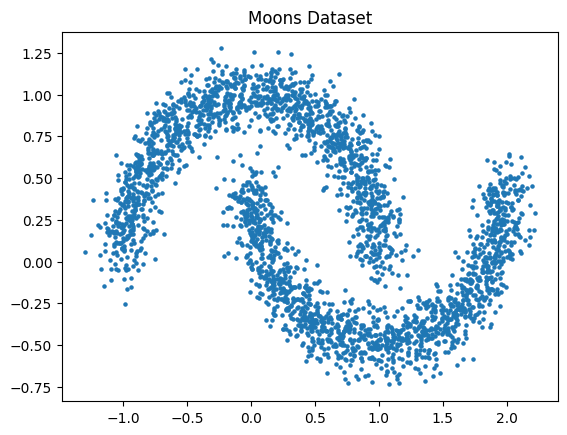

In [19]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

torch.manual_seed(0)
X, y = make_moons(
    n_samples=3000,
    noise=0.1,
    random_state=42
)

X = torch.tensor(X, dtype=torch.float32)

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

plt.scatter(X[:,0], X[:,1], s=5)
plt.title("Moons Dataset")
plt.show()

## Training Real-Non-volume Preserving Model for this 2D Dataset

Training the Model on [cuda]
Epoch [0 / 1500] | Avg Loss: 2.4548


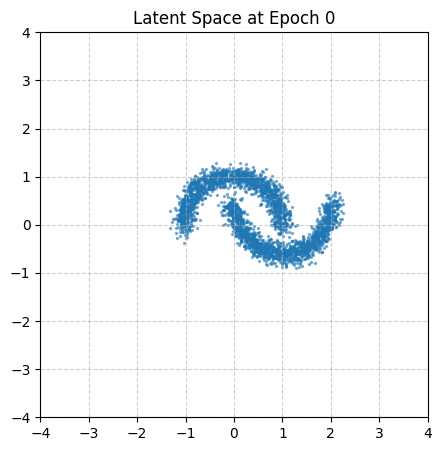

Epoch [100 / 1500] | Avg Loss: 1.2465


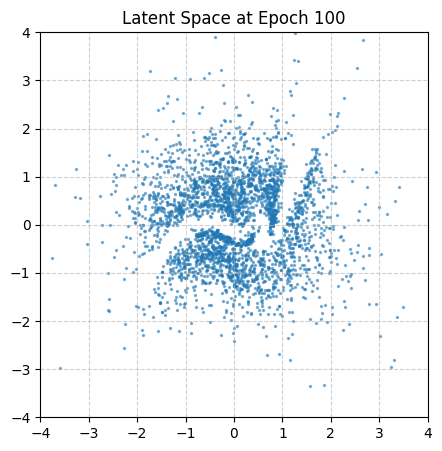

Epoch [200 / 1500] | Avg Loss: 1.1130


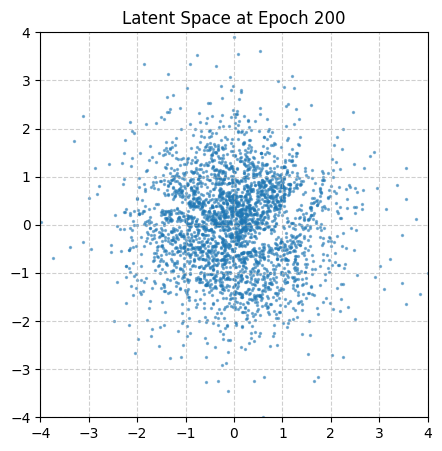

Epoch [300 / 1500] | Avg Loss: 1.0684


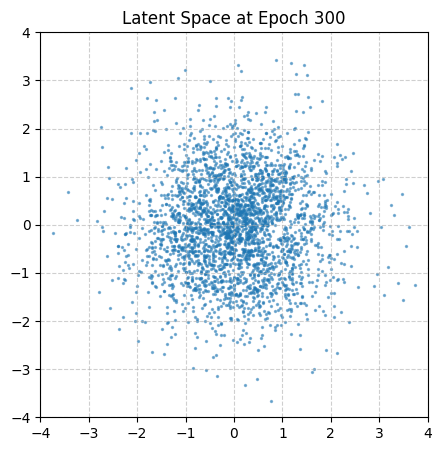

Epoch [400 / 1500] | Avg Loss: 1.0517


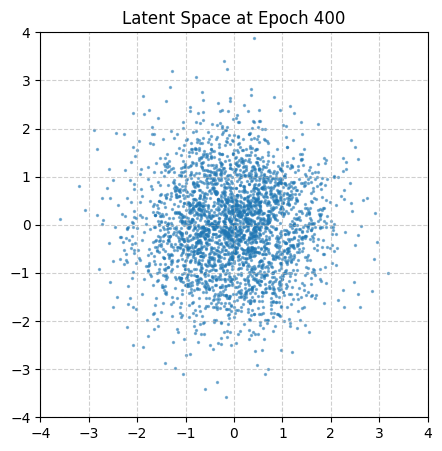

Epoch [500 / 1500] | Avg Loss: 1.0421


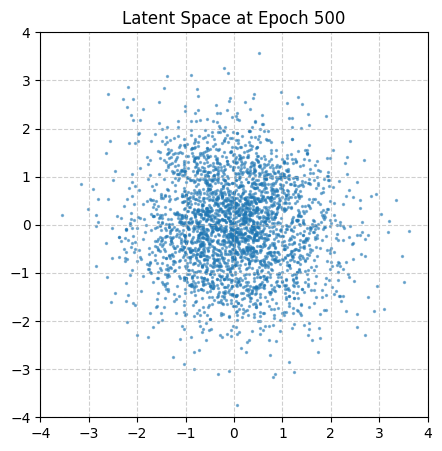

Epoch [600 / 1500] | Avg Loss: 1.0407


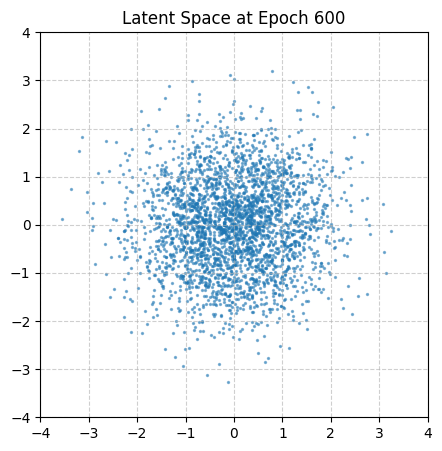

Epoch [700 / 1500] | Avg Loss: 1.0386


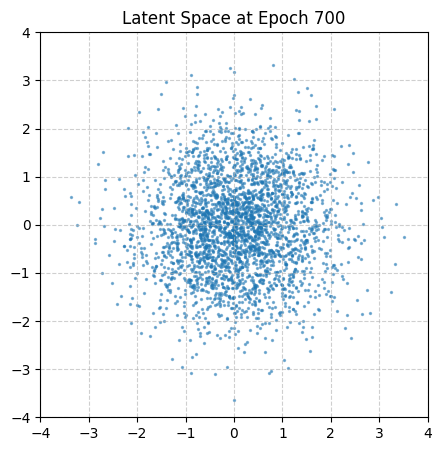

Epoch [800 / 1500] | Avg Loss: 1.0411


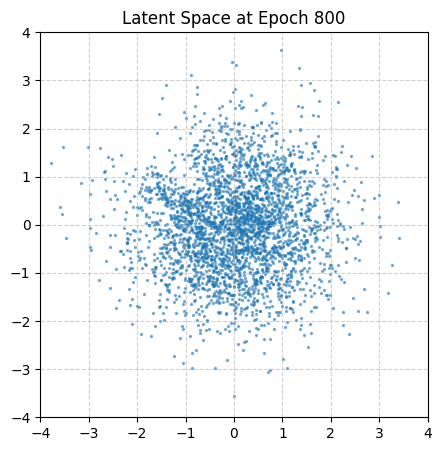

Epoch [900 / 1500] | Avg Loss: 1.0348


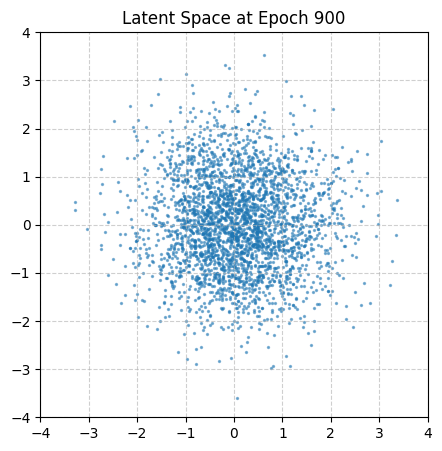

Epoch [1000 / 1500] | Avg Loss: 1.0274


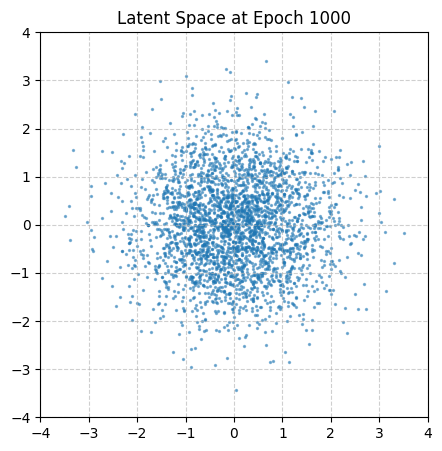

Epoch [1100 / 1500] | Avg Loss: 1.0338


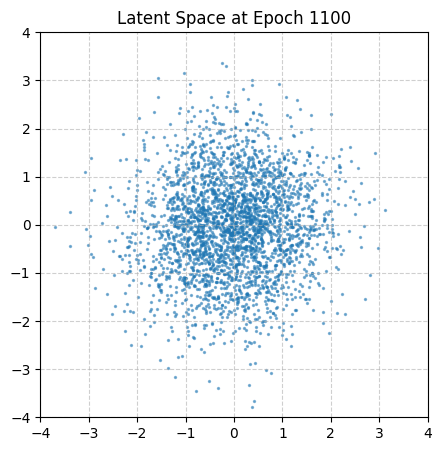

Epoch [1200 / 1500] | Avg Loss: 1.0320


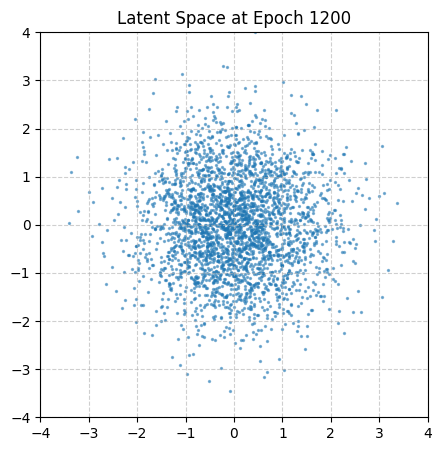

Epoch [1300 / 1500] | Avg Loss: 1.0190


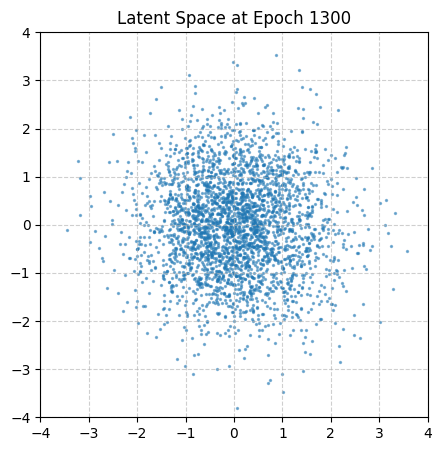

Epoch [1400 / 1500] | Avg Loss: 1.0174


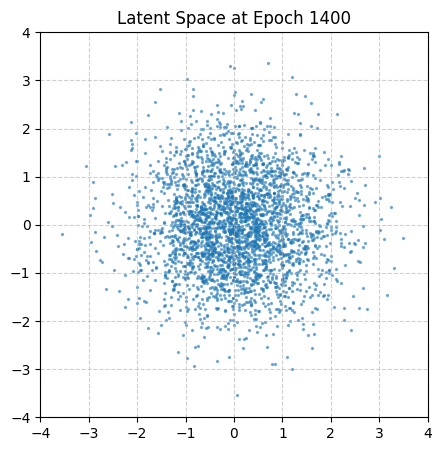

In [20]:
masks_2d = torch.tensor([
    [1,0],
    [0,1]
] * 4).to(device)

model_2d = NormalizingFlowModel(in_features = X.shape[-1], hidden_dim = 256, out_features = X.shape[-1], mask = masks_2d, n_layers = 8).to(device)
X = X.to(device)
optim = torch.optim.Adam(model_2d.parameters(), lr = 1e-4, weight_decay=1e-4)
trained_model_2d = train_model(X, dataloader, model = model_2d, epochs = 1500, optimizer = optim)

In [21]:
trained_model_2d.eval()
with torch.no_grad():
    z, _ = trained_model_2d(X)

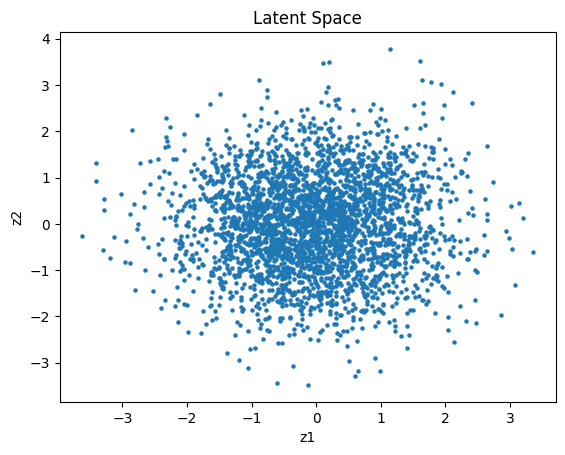

In [27]:
import matplotlib.pyplot as plt

z_np = z.detach().cpu().numpy()

plt.scatter(z_np[:,0], z_np[:,1], s=5)

plt.title("Latent Space")

plt.xlabel("z1")

plt.ylabel("z2")

plt.show()

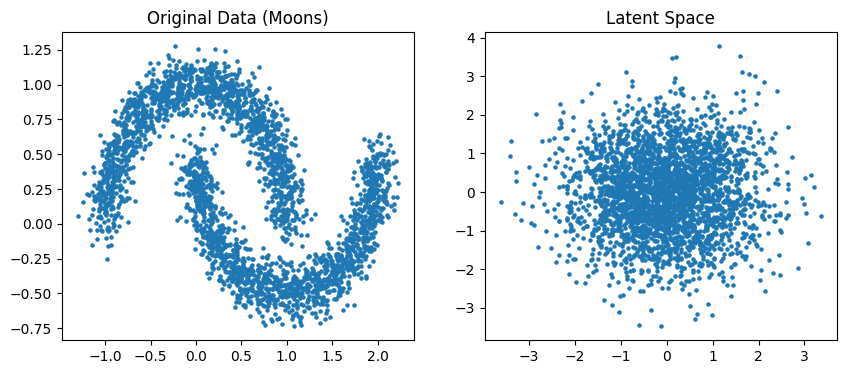

In [28]:
plt.figure(figsize=(10,4))

# original data
plt.subplot(1,2,1)
plt.scatter(X.detach().cpu().numpy()[:,0], X.detach().cpu().numpy()[:,1], s=5)
plt.title("Original Data (Moons)")

# latent space
plt.subplot(1,2,2)
plt.scatter(z_np[:,0], z_np[:,1], s=5)
plt.title("Latent Space")

plt.show()

In [35]:
with torch.no_grad():
    z_sample = torch.randn(3500, 2, device=device)
    x_sample = trained_model_2d.inverse(z_sample)

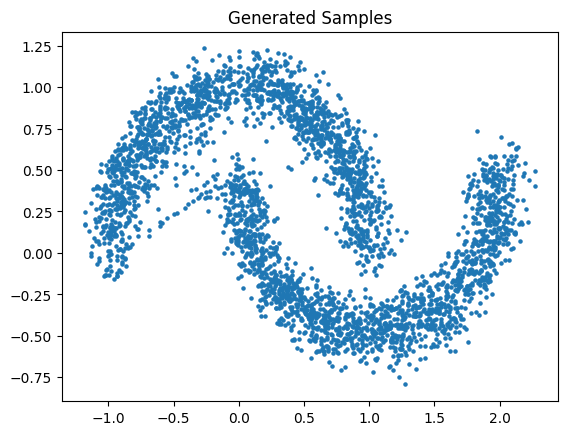

In [36]:
plt.scatter(x_sample.detach().cpu().numpy()[:,0], x_sample.detach().cpu().numpy()[:,1], s=5)

plt.title("Generated Samples")

plt.show()

In [26]:
print("""
# What I Changed?
1. Removed the LayerNorm --> This was the main reason why my model was tearing the latent space
2. Added weight decay in optimizer (this was not the cause of not learning the transformation well)
3. Reduced number of LinearLayers (this was not the cause of not learning the transformation well)
4. Increased hidden_him from 128 to 256 (this was not the cause of not learning the transformation well)
5. Visualized latent space after every 100 epochs
""")


# What I Changed?
1. Removed the LayerNorm --> This was the main reason why my model was tearing the latent space
2. Added weight decay in optimizer (this was not the cause of not learning the transformation well)
3. Reduced number of LinearLayers (this was not the cause of not learning the transformation well)
4. Increased hidden_him from 128 to 256 (this was not the cause of not learning the transformation well)
5. Visualized latent space after every 100 epochs



## Note:
1. Removing the LayerNormalization helped because I didn't accounted for the Jacobian for LayerNormalization
2. Added weight decay in optimizer
3. reduced the complexity of the scale and shift neural network, because learning 2d data is not that complex
4. increased hidden_dim from 128 to 256 (for 2d dataset, hidden_dim = 64, will work)
5. Visualized the latent space